# Day 3 — Training Dynamics & Optimization

## Note 3.2 — Overfitting, and What to Do About It

### Learning goal and outcome

Note 3.1 made the network learn quickly. This notebook studies the opposite failure: a network can become **very good at reproducing the training data while becoming worse at making predictions on new data**. That failure is called **overfitting**.

The central question is not simply, “How do I stop overfitting?” It is:

> **How do I know that I am overfitting, what exactly is going wrong, and which intervention addresses that particular problem?**

You will deliberately create overfitting, learn to recognise it from both loss and metric curves, and then compare four standard ways of controlling it: **reducing model capacity, weight decay, dropout, and early stopping**.

One more idea is especially important: **a validation result contains noise**. A configuration that scores 0.01 higher on one validation split has not automatically improved the model. You need to know how much the score naturally moves when the data changes slightly.

By the end, you should be able to:
- recognise overfitting from training/validation curves;
- explain what model capacity means and why it interacts with dataset size;
- distinguish what validation loss measures from what ROC-AUC measures;
- explain what each regularisation method actually changes;
- recognise both under-regularisation and over-regularisation;
- measure the noise in your validation result before treating a small difference as an improvement.

### Objectives

- Explain why the amount of training data, relative to model capacity, determines whether serious memorisation is possible.
- Produce overfitting deliberately and identify it from both loss and metric curves.
- Explain why validation loss and validation AUC can tell different stories.
- Compare four interventions: reduced capacity, weight decay, dropout, and early stopping.
- Recognise the characteristic signs of **over-regularisation**.
- Measure the variability of your own validation set and use that measurement when interpreting close results.

### Dataset

**German Credit (Statlog)**, via `sklearn.datasets.fetch_openml('credit-g')` — 1,000 rows, 20 mixed numeric/categorical features, binary good/bad credit risk, roughly 70/30 class balance. It downloads without credentials and caches locally.

Why swap away from Bank Marketing? Section 1 measures the difference rather than assuming it. The Day 2 Bank Marketing model has about 36,000 training rows but only 5,377 parameters. That is a very different capacity-to-data situation from this notebook's deliberately small 500-row training set.

We split the German Credit data into **500 training / 250 validation / 250 test** rows. The small training set is intentional: it makes the interaction between model capacity and data visible.

**A note on this dataset.** German Credit dates from 1994 and includes attributes such as `personal_status` and `age` that no responsible credit model would use as-is today. It remains a standard benchmark because decades of published results make it a known quantity. The fairness questions it raises are real and belong to a dedicated treatment; here it is a vehicle for studying generalisation, and we will not be deploying anything.

### Table of contents

1. [Why 45,000 rows cannot teach this](#s1)
2. [German Credit through the Day 2 pipeline](#s2)
3. [Memorising 500 rows on purpose](#s3)
4. [Two metrics, two stories](#s4)
5. [Capacity first: the cheapest regulariser is a smaller model](#s5)
6. [Weight decay](#s6)
7. [Dropout, and the bug everyone writes once](#s7)
8. [Early stopping](#s8)
9. [Over-regularising, and how much noise your validation set has](#s9)
10. [What to reach for first](#s10)


In [1]:
# torch 2.14.0 | scikit-learn 1.8.0 | numpy 2.4.4 | pandas 3.0.2 | matplotlib 3.10.8
import os, io, time, zipfile, urllib.request, copy
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

DEVICE = torch.device("cpu")     # everything here is small; CPU keeps timings comparable
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print("torch", torch.__version__, "| device", DEVICE)
loss_fn = nn.BCEWithLogitsLoss()


torch 2.14.0+cpu | device cpu


<a id="s1"></a>
## 1. Why 45,000 rows cannot teach this

Before swapping datasets, let's test the reason for the swap.

The problem we want to study is **overfitting**: a model having enough flexibility to fit details that are specific to its training examples rather than details that generalise to new examples.

A useful first diagnostic is the relationship between **model capacity** and **amount of training data**.

- A **parameter** is a trainable number in the model, such as a weight or bias.
- **Model capacity** is the model's ability to represent different functions. More parameters often give a model more capacity, although parameter count is only a rough proxy for capacity.
- A **training example** is one row the model is allowed to learn from.

If there are vastly more training examples than parameters, the model has relatively little room to give every individual row its own special treatment. It is pushed towards finding patterns shared across many examples.

If there are many more parameters than training examples, the model has much more freedom. It can potentially fit individual examples or small groups of examples instead of learning only the broad structure.

So **parameters per training example is a useful diagnostic here, not a law of machine learning**. The experiment below measures it for the Day 2 setup rather than assuming that the ratio alone determines whether overfitting will occur.


In [2]:
# Rebuild the Day 2 Bank Marketing setup just far enough to measure it.
DATA_DIR = "data"; os.makedirs(DATA_DIR, exist_ok=True)
CSV = os.path.join(DATA_DIR, "bank-full.csv")
if not os.path.exists(CSV):
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    raw = urllib.request.urlopen(url, timeout=120).read()
    outer = zipfile.ZipFile(io.BytesIO(raw))
    inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
    open(CSV, "wb").write(inner.read("bank-full.csv"))

bm = pd.read_csv(CSV, sep=";")
bm_y = (bm["y"] == "yes").astype(np.float32).values
bm_X = bm.drop(columns=["y", "duration"])
bnum = bm_X.select_dtypes(include="number").columns.tolist()
bcat = [c for c in bm_X.columns if c not in bnum]
bXtr, bXva, bytr, byva = train_test_split(bm_X, bm_y, test_size=0.2, random_state=SEED, stratify=bm_y)
bpre = ColumnTransformer([("n", StandardScaler(), bnum),
                          ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), bcat)])
bA = bpre.fit_transform(bXtr).astype(np.float32); bV = bpre.transform(bXva).astype(np.float32)

bm_params = 50*64+64 + 64*32+32 + 32*1+1
print(f"Bank Marketing : {bA.shape[0]:,} train rows, {bm_params:,} parameters "
      f"-> {bm_params/bA.shape[0]:.3f} parameters per training example")


Bank Marketing : 36,168 train rows, 5,377 parameters -> 0.149 parameters per training example


In [3]:
# Train the Day 2 model far past its useful life and watch for memorisation.
bXt = torch.tensor(bA); bYt = torch.tensor(bytr).unsqueeze(1)
bXv = torch.tensor(bV); bYv = torch.tensor(byva).unsqueeze(1)
torch.manual_seed(SEED)
bmodel = nn.Sequential(nn.Linear(bA.shape[1],64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
bopt = torch.optim.AdamW(bmodel.parameters(), lr=1e-3)
bl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(bXt,bYt), batch_size=256,
                                 shuffle=True, generator=torch.Generator().manual_seed(SEED))
bm_hist=[]
t0=time.time()
for ep in range(1, 41):
    bmodel.train()
    for xb,yb in bl:
        bopt.zero_grad(); loss_fn(bmodel(xb),yb).backward(); bopt.step()
    bmodel.eval()
    with torch.no_grad():
        a=bmodel(bXt); b=bmodel(bXv)
        bm_hist.append(dict(ep=ep, trl=loss_fn(a,bYt).item(), vl=loss_fn(b,bYv).item(),
            tra=roc_auc_score(bytr,torch.sigmoid(a).numpy()), va=roc_auc_score(byva,torch.sigmoid(b).numpy())))
print(f"40 epochs in {time.time()-t0:.0f}s")
print(f"{'epoch':>6}{'train loss':>12}{'val loss':>10}{'train AUC':>11}{'val AUC':>9}{'gap':>8}")
for x in bm_hist:
    if x["ep"] in (1,5,10,20,30,40):
        print(f"{x['ep']:>6}{x['trl']:>12.4f}{x['vl']:>10.4f}{x['tra']:>11.4f}{x['va']:>9.4f}{x['tra']-x['va']:>8.4f}")


40 epochs in 10s
 epoch  train loss  val loss  train AUC  val AUC     gap
     1      0.3105    0.3084     0.7595   0.7666 -0.0071
     5      0.2892    0.2921     0.7945   0.7874  0.0070
    10      0.2804    0.2879     0.8087   0.7927  0.0160
    20      0.2708    0.2883     0.8259   0.7939  0.0320
    30      0.2635    0.2901     0.8368   0.7920  0.0448
    40      0.2572    0.2961     0.8479   0.7861  0.0618


There it is, measured rather than asserted.

After forty epochs — far more than anyone would normally need for this small demonstration — a gap opens between training and validation AUC, and validation AUC peaks and then drifts down slightly. So the Bank Marketing model does show some overfitting.

But notice the scale of the effect. Training loss is still around 0.26 rather than approaching zero, and training AUC is still well below 1.0. The model has **not memorised the training rows** in the way we are about to make the German Credit model memorise its 500 rows.

The parameter-to-example ratio helps explain why. The Bank Marketing model has roughly 0.15 parameters per training example. That does not make memorisation mathematically impossible in every sense, but it gives this particular network far less capacity per example than the German Credit experiment.

This matters for teaching and for experiments generally:

> **A method cannot look useful if the problem it is designed to solve is barely present.**

If we added dropout to the Bank Marketing experiment and saw almost no change, that would not prove that dropout is useless. It would mostly tell us that this experiment is a poor place to demonstrate its effect.

The broader engineering lesson is even more important. Before evaluating a regulariser, architecture, optimiser, or other intervention, first establish that the failure mode it is supposed to address can actually be observed in your experiment.


<a id="s2"></a>
## 2. German Credit through the Day 2 pipeline

The dataset is changing; the basic modelling pipeline should not.

This is an important experimental principle: **change one major thing at a time when you want to understand causality**. Here we keep the preprocessing, tensor construction, MLP pattern, and training-loop structure familiar from Day 2, while changing the dataset and deliberately using a much smaller training set.

A few terms used in the code:

- `ColumnTransformer` applies different preprocessing to different groups of columns.
- `StandardScaler` standardises numeric features.
- `OneHotEncoder` converts categorical values into indicator columns.
- `TensorDataset` packages tensors so they can be consumed by a PyTorch `DataLoader`.
- The **training set** is used to fit the model.
- The **validation set** is used to make development choices such as model size or when to stop.
- The **test set** is held back until the end so it can provide a less biased estimate of performance.

The preprocessing is fitted on the training data only. That prevents information from the validation or test rows from influencing the transformation learned from the training set.


In [4]:
gc = fetch_openml("credit-g", version=1, as_frame=True)
X_raw = gc.data.copy()
y_raw = (gc.target == "bad").astype(np.float32).values      # positive class = bad credit risk

gnum = X_raw.select_dtypes(include="number").columns.tolist()
gcat = [c for c in X_raw.columns if c not in gnum]
print(f"rows {X_raw.shape[0]}  numeric {len(gnum)}  categorical {len(gcat)}")
print(f"class balance: bad {y_raw.mean():.3f} / good {1-y_raw.mean():.3f}")

# 3-way split: 500 train / 250 val / 250 test
X_tr_r, X_tmp, y_tr, y_tmp = train_test_split(X_raw, y_raw, train_size=500,
                                              random_state=SEED, stratify=y_raw)
X_va_r, X_te_r, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                              random_state=SEED, stratify=y_tmp)

pre = ColumnTransformer([("n", StandardScaler(), gnum),
                         ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gcat)])
A_tr = pre.fit_transform(X_tr_r).astype(np.float32)   # fit on TRAIN only
A_va = pre.transform(X_va_r).astype(np.float32)
A_te = pre.transform(X_te_r).astype(np.float32)

D = A_tr.shape[1]
Xt = torch.tensor(A_tr); Yt = torch.tensor(y_tr).unsqueeze(1)
Xv = torch.tensor(A_va); Yv = torch.tensor(y_va).unsqueeze(1)
Xs = torch.tensor(A_te); Ys = torch.tensor(y_te).unsqueeze(1)

print(f"\ntrain {A_tr.shape}  val {A_va.shape}  test {A_te.shape}")
print(f"majority-class accuracy on val: {max(y_va.mean(), 1-y_va.mean()):.4f}")
print(f"majority-class accuracy on test: {max(y_te.mean(), 1-y_te.mean()):.4f}")


rows 1000  numeric 7  categorical 13
class balance: bad 0.300 / good 0.700

train (500, 61)  val (250, 61)  test (250, 61)
majority-class accuracy on val: 0.7000
majority-class accuracy on test: 0.7000


In [5]:
# The same MLP shape as Day 2, now sized for this feature count.
def make_mlp(hidden=(256,128), p_drop=0.0, seed=SEED, d_in=None):
    torch.manual_seed(seed)
    d_in = d_in or D
    layers, prev = [], d_in
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        if p_drop > 0: layers.append(nn.Dropout(p_drop))
        prev = h
    layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*layers)

def n_params(m): return sum(p.numel() for p in m.parameters())

big = make_mlp()
print(f"features                    {D}")
print(f"model {str((256,128)):<12}          {n_params(big):,} parameters")
print(f"parameters per training row {n_params(big)/len(A_tr):.1f}")
print()
print(f"compare Bank Marketing:     {bm_params/bA.shape[0]:.3f} parameters per training row")
print(f"ratio:                      {(n_params(big)/len(A_tr)) / (bm_params/bA.shape[0]):,.0f}x more capacity per example")


features                    61
model (256, 128)            48,897 parameters
parameters per training row 97.8

compare Bank Marketing:     0.149 parameters per training row
ratio:                      658x more capacity per example


Roughly a hundred parameters for every training row, compared with Bank Marketing's fraction of one. That is a very large change in **capacity per training example**, and we achieved it without introducing new modelling machinery.

The important phrase is “capacity per example.” It does **not** mean that every parameter stores one row. Neural networks do not work that way. It means that, relative to the amount of data available, the model has much more freedom to construct a complicated function.

That freedom makes memorisation possible. The next section deliberately pushes the model in that direction.

> **🖼 Image prompt** — A two-panel visual metaphor for capacity versus data, titled "Can this model memorise?". Left panel labelled "Bank Marketing — 0.15 params/row": a very large grid of tiny dots representing 36,000 data rows, with a small container beside it labelled "5,377 parameters"; an arrow from grid to container is blocked by a bold "won't fit" symbol, with the caption "forced to find general structure". Right panel labelled "German Credit — 98 params/row": a small scatter of 500 dots beside a large container labelled "48,897 parameters", arrow flowing in freely, caption "can store every row individually". Keep both containers drawn to relative scale so the contrast is immediate. Flat infographic style, two muted colours plus one accent.


<a id="s3"></a>
## 3. Memorising 500 rows on purpose

Now we deliberately create the failure we want to study.

The model is large relative to the 500 training examples, and we train it for long enough without an explicit regularisation method. The purpose is **not** to build a useful credit model. The purpose is to make the difference between training performance and generalisation visible.

The key vocabulary:

- **Training performance** tells us how well the model fits examples it was allowed to learn from.
- **Validation performance** tells us how well that same model behaves on examples it did not train on.
- **Generalisation** means performing well on new examples drawn from the same underlying problem.
- **Overfitting** occurs when continued training improves the fit to the training data while performance on unseen data stops improving or gets worse.

Watch for the point where those two stories separate.


In [6]:
def run(hidden=(256,128), p_drop=0.0, wd=0.0, lr=1e-3, epochs=60, bs=32,
        seed=SEED, track_test=False):
    """Train and return per-epoch history plus the best-val-loss checkpoint."""
    model = make_mlp(hidden, p_drop, seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    g = torch.Generator().manual_seed(seed)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, Yt),
                                         batch_size=bs, shuffle=True, generator=g)
    hist, best = [], dict(vl=float("inf"), epoch=0, state=None)
    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            a, b = model(Xt), model(Xv)
            pa, pb = torch.sigmoid(a).numpy().ravel(), torch.sigmoid(b).numpy().ravel()
            rec = dict(ep=ep,
                       trl=loss_fn(a, Yt).item(), vl=loss_fn(b, Yv).item(),
                       tra=roc_auc_score(y_tr, pa), va=roc_auc_score(y_va, pb),
                       tracc=accuracy_score(y_tr, pa > 0.5), vacc=accuracy_score(y_va, pb > 0.5))
            if track_test:
                pc = torch.sigmoid(model(Xs)).numpy().ravel()
                rec["tea"] = roc_auc_score(y_te, pc)
        if rec["vl"] < best["vl"]:
            best = dict(vl=rec["vl"], epoch=ep, state=copy.deepcopy(model.state_dict()))
        hist.append(rec)
    return dict(hist=hist, best=best, model=model)

t0 = time.time()
base = run()
print(f"60 epochs on 500 rows: {time.time()-t0:.1f}s\n")
h = base["hist"]
print(f"{'epoch':>6}{'train loss':>12}{'val loss':>10}{'train AUC':>11}{'val AUC':>9}{'train acc':>11}")
for x in h:
    if x["ep"] in (1,3,5,7,10,15,20,30,45,60):
        print(f"{x['ep']:>6}{x['trl']:>12.4f}{x['vl']:>10.4f}{x['tra']:>11.4f}{x['va']:>9.4f}{x['tracc']:>11.4f}")


60 epochs on 500 rows: 1.1s

 epoch  train loss  val loss  train AUC  val AUC  train acc
     1      0.5797    0.5893     0.7818   0.7154     0.7000
     3      0.4755    0.4918     0.8429   0.8184     0.7560
     5      0.4049    0.4733     0.8830   0.8095     0.8240
     7      0.3302    0.5004     0.9236   0.7888     0.8700
    10      0.2184    0.5745     0.9747   0.7640     0.9300
    15      0.0707    0.7947     1.0000   0.7327     0.9980
    20      0.0193    1.0120     1.0000   0.7381     1.0000
    30      0.0043    1.2349     1.0000   0.7435     1.0000
    45      0.0013    1.4541     1.0000   0.7422     1.0000
    60      0.0006    1.5929     1.0000   0.7424     1.0000


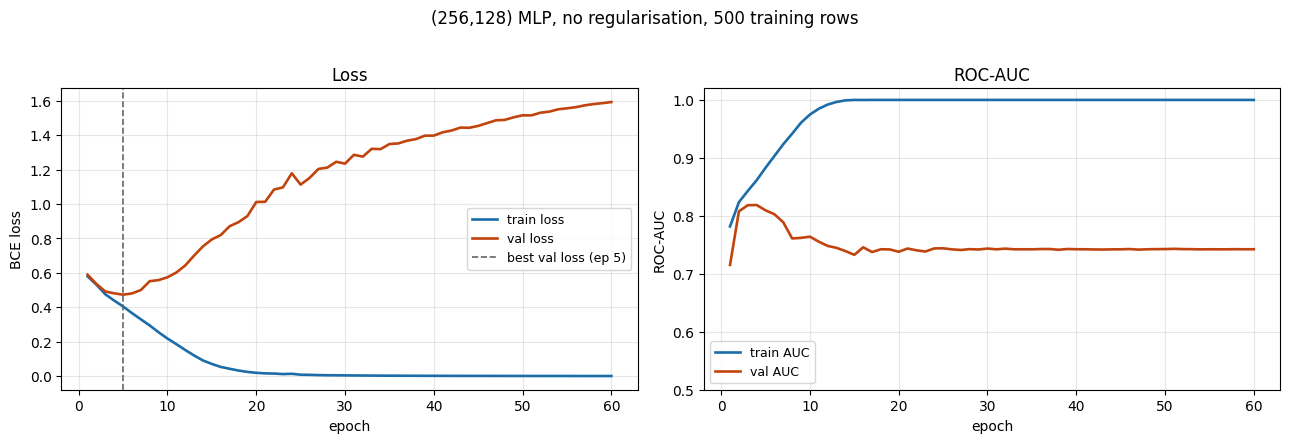

train AUC reaches      1.0000
train accuracy reaches 1.0000
train loss falls to    0.000594
val loss rises from    0.4733 (ep 5) to 1.5929 (ep 60)
  -> val loss is 3.4x worse at the end than at its best


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
eps = [x["ep"] for x in h]
axes[0].plot(eps, [x["trl"] for x in h], label="train loss", color="#1b6ca8", lw=1.9)
axes[0].plot(eps, [x["vl"]  for x in h], label="val loss",   color="#c1440e", lw=1.9)
axes[0].axvline(base["best"]["epoch"], ls="--", c="0.4", lw=1.2,
                label=f"best val loss (ep {base['best']['epoch']})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].set_title("Loss")
axes[1].plot(eps, [x["tra"] for x in h], label="train AUC", color="#1b6ca8", lw=1.9)
axes[1].plot(eps, [x["va"]  for x in h], label="val AUC",   color="#c1440e", lw=1.9)
axes[1].set_ylim(0.5, 1.02)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("ROC-AUC"); axes[1].set_title("ROC-AUC")
for a in axes: a.legend(fontsize=9); a.grid(alpha=0.3)
plt.suptitle("(256,128) MLP, no regularisation, 500 training rows", y=1.02)
plt.tight_layout(); plt.show()

print(f"train AUC reaches      {max(x['tra'] for x in h):.4f}")
print(f"train accuracy reaches {max(x['tracc'] for x in h):.4f}")
print(f"train loss falls to    {min(x['trl'] for x in h):.6f}")
print(f"val loss rises from    {base['best']['vl']:.4f} (ep {base['best']['epoch']}) to {h[-1]['vl']:.4f} (ep 60)")
print(f"  -> val loss is {h[-1]['vl']/base['best']['vl']:.1f}x worse at the end than at its best")


This is textbook overfitting, and unlike Section 1 it took under three seconds to produce.

Training AUC reaches 1.0 — the model ranks all 500 training rows perfectly. Training loss also falls towards zero, which means the model is not merely getting the training labels right; it is becoming increasingly confident about them.

Meanwhile, validation loss reaches its minimum early and then climbs. Validation AUC also stops improving and begins to drift down.

The left panel shows the classic visual signature:

**training and validation curves improve together at first; then the validation curve turns while the training curve continues improving.**

That separation is the important event. The model is still becoming better at fitting the training examples, but those extra improvements are no longer transferring to unseen examples.

This is the distinction between **fitting** and **generalising**:

- fitting asks, “How well can I explain the examples I was given?”
- generalising asks, “How well does what I learned transfer to examples I have not seen?”

The model does not suddenly become incapable of learning after the turning point. It keeps learning — but increasingly learns details that are specific to the training set.

Now look at the right panel, because the metric there tells a different story.


<a id="s4"></a>
## 4. Two metrics, two stories

The loss panel says the model is becoming badly overconfident on validation data. The AUC panel says the deterioration in ranking is much smaller.

Both measurements are calculated from the same predictions on the same validation rows. The reason they disagree is that **they measure different properties of those predictions**.

Before deciding which curve to monitor, you need to understand exactly what each metric can and cannot see.


In [8]:
print(f"{'epoch':>6}{'val loss':>10}{'val AUC':>10}{'val acc':>10}")
for x in h:
    if x["ep"] in (1,4,7,10,20,40,60):
        print(f"{x['ep']:>6}{x['vl']:>10.4f}{x['va']:>10.4f}{x['vacc']:>10.4f}")

vl = [x["vl"] for x in h]; va = [x["va"] for x in h]
print()
print(f"val loss : best {min(vl):.4f} @ep{int(np.argmin(vl))+1}  ->  final {vl[-1]:.4f}   "
      f"({100*(vl[-1]-min(vl))/min(vl):+.0f}%)")
print(f"val AUC  : best {max(va):.4f} @ep{int(np.argmax(va))+1}  ->  final {va[-1]:.4f}   "
      f"({100*(va[-1]-max(va))/max(va):+.1f}%)")


 epoch  val loss   val AUC   val acc
     1    0.5893    0.7154    0.7000
     4    0.4810    0.8187    0.7680
     7    0.5004    0.7888    0.7240
    10    0.5745    0.7640    0.7200
    20    1.0120    0.7381    0.7640
    40    1.3978    0.7424    0.7400
    60    1.5929    0.7424    0.7400

val loss : best 0.4733 @ep5  ->  final 1.5929   (+237%)
val AUC  : best 0.8187 @ep4  ->  final 0.7424   (-9.3%)


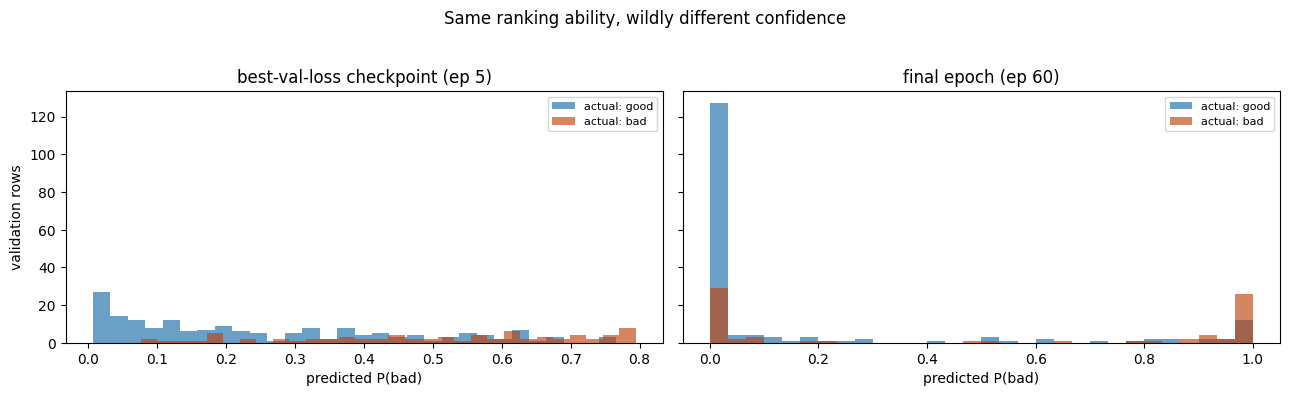

predictions above 0.99 or below 0.01:
  early checkpoint:   0.8% of validation rows
  final epoch     :  69.2% of validation rows

mean predicted P(bad) for rows that are actually BAD:
  early 0.508   final 0.498
mean predicted P(bad) for rows that are actually GOOD:
  early 0.247   final 0.155


In [9]:
# Why they disagree: look at the predicted probabilities early vs late.
early = make_mlp(); early.load_state_dict(base["best"]["state"]); early.eval()
late = base["model"]; late.eval()
with torch.no_grad():
    p_early = torch.sigmoid(early(Xv)).numpy().ravel()
    p_late  = torch.sigmoid(late(Xv)).numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, p, tag in [(axes[0], p_early, f"best-val-loss checkpoint (ep {base['best']['epoch']})"),
                   (axes[1], p_late,  "final epoch (ep 60)")]:
    ax.hist(p[y_va==0], bins=30, alpha=0.65, label="actual: good", color="#1b6ca8")
    ax.hist(p[y_va==1], bins=30, alpha=0.65, label="actual: bad",  color="#c1440e")
    ax.set_title(tag); ax.set_xlabel("predicted P(bad)"); ax.legend(fontsize=8)
axes[0].set_ylabel("validation rows")
plt.suptitle("Same ranking ability, wildly different confidence", y=1.03)
plt.tight_layout(); plt.show()

print(f"predictions above 0.99 or below 0.01:")
print(f"  early checkpoint: {((p_early>0.99)|(p_early<0.01)).mean():6.1%} of validation rows")
print(f"  final epoch     : {((p_late >0.99)|(p_late <0.01)).mean():6.1%} of validation rows")
print()
print(f"mean predicted P(bad) for rows that are actually BAD:")
print(f"  early {p_early[y_va==1].mean():.3f}   final {p_late[y_va==1].mean():.3f}")
print(f"mean predicted P(bad) for rows that are actually GOOD:")
print(f"  early {p_early[y_va==0].mean():.3f}   final {p_late[y_va==0].mean():.3f}")


Now the disagreement makes sense.

### ROC-AUC: “Did I put the bad cases above the good cases?”

**ROC-AUC measures ranking quality.** Informally, it asks:

> If I randomly choose one bad-credit row and one good-credit row, how often does the model assign the bad row a higher score?

Because AUC cares about the ordering of scores, it is largely insensitive to a transformation that preserves that ordering. For example, making predictions more extreme without changing their order can leave AUC unchanged.

### Cross-entropy loss: “Were the predictions correct, and how confident were they?”

`BCEWithLogitsLoss` evaluates the quality of the predicted probabilities implied by the logits. A confident mistake is much more costly than a mistake made with moderate confidence.

For example, predicting 0.99 for an event that does not happen is treated much more harshly than predicting 0.60 for the same event.

That gives us two different questions:

- **AUC:** Are the risky cases generally ranked above the less risky cases?
- **Loss:** Are the predictions, including their confidence, compatible with the observed outcomes?

The overfitted model has therefore retained much of its ranking ability while becoming increasingly extreme in its predictions. That is why the AUC curve can look relatively stable while validation loss becomes much worse.

The histogram makes this visible: the final model pushes many predictions towards the extremes, while the earlier checkpoint keeps more predictions in the middle.

### Which metric should you act on?

There is no universal answer. The correct metric depends on what the model's output is used for.

- If the output is used mainly for **ranking or prioritisation** — for example, reviewing the 100 highest-risk applications — AUC directly describes an important part of the task.
- If the output is used as a **probability** in an expected-loss calculation, threshold decision, or human-facing risk estimate, probability quality and calibration matter much more.
- If you are deciding **when to stop training**, validation loss can provide a useful stopping signal here because it reacts strongly to the overconfidence that appears after the best checkpoint.

The important habit is not “always use loss” or “always use AUC.” It is:

> **Know what failure modes your metric can see, and check another measurement for failures it cannot see.**

**Check your understanding.** Suppose a bug multiplies every output logit by 3 before the sigmoid. Which of validation AUC, validation loss, and validation accuracy would change, and which could remain unchanged? Explain your answer in terms of ranking, thresholding, and confidence.


<a id="s5"></a>
## 5. Capacity first: the cheapest regulariser is a smaller model

Once you see overfitting, it is tempting to add dropout or weight decay immediately.

Start with the simplest question instead:

> **Do I actually need a model this large?**

Section 2 showed that the model has much more capacity than the 500 training rows require. The most direct response to excess capacity is to reduce the capacity.

A smaller network has fewer trainable parameters and therefore fewer degrees of freedom. That can make it harder for the model to memorise individual training examples.

This is often called a **regularisation effect**: we are constraining the set of functions the model can represent so that solutions that fit arbitrary training-set details become harder to reach.

Capacity reduction is different from the other interventions in this notebook because it changes the model itself rather than adding a penalty or changing when training stops.


In [10]:
cap_runs = {}
for hidden in [(256,128), (64,32), (16,8), (8,)]:
    r = run(hidden=hidden)
    cap_runs[hidden] = r
    hh = r["hist"]
    vl_ = [x["vl"] for x in hh]; va_ = [x["va"] for x in hh]
    print(f"{str(hidden):<12} params {n_params(make_mlp(hidden)):>7,}  "
          f"best val loss {min(vl_):.4f}@{int(np.argmin(vl_))+1:>2}  "
          f"best val AUC {max(va_):.4f}  final val AUC {va_[-1]:.4f}  "
          f"final train AUC {hh[-1]['tra']:.4f}")


(256, 128)   params  48,897  best val loss 0.4733@ 5  best val AUC 0.8187  final val AUC 0.7424  final train AUC 1.0000


(64, 32)     params   6,081  best val loss 0.4706@10  best val AUC 0.8158  final val AUC 0.7253  final train AUC 1.0000


(16, 8)      params   1,137  best val loss 0.4644@20  best val AUC 0.8244  final val AUC 0.7650  final train AUC 0.9552


(8,)         params     505  best val loss 0.4569@37  best val AUC 0.8360  final val AUC 0.8163  final train AUC 0.8784


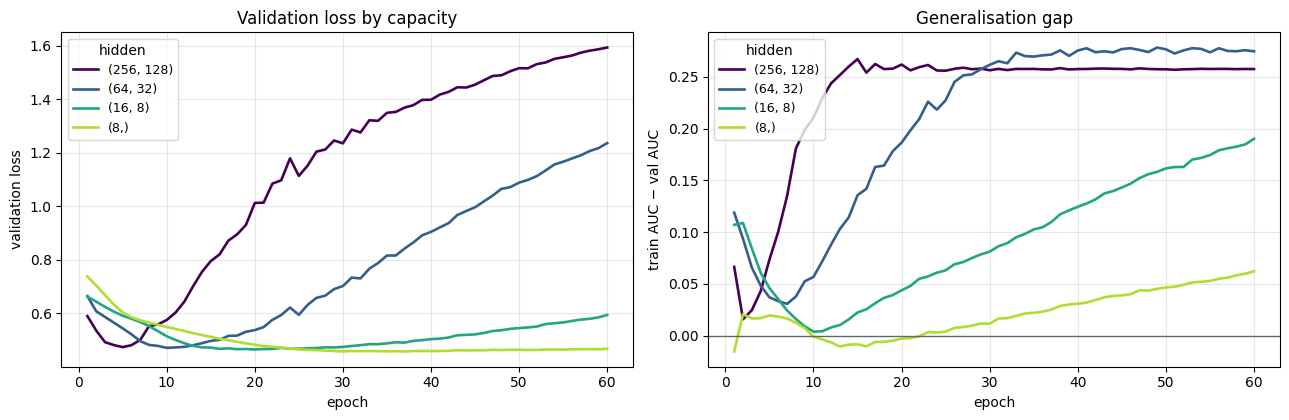

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
cols = plt.cm.viridis(np.linspace(0, 0.88, len(cap_runs)))
for c, (hid, r) in zip(cols, cap_runs.items()):
    hh = r["hist"]; e = [x["ep"] for x in hh]
    axes[0].plot(e, [x["vl"] for x in hh], color=c, lw=1.9, label=str(hid))
    axes[1].plot(e, [x["tra"]-x["va"] for x in hh], color=c, lw=1.9, label=str(hid))
axes[0].set_ylabel("validation loss"); axes[0].set_title("Validation loss by capacity")
axes[1].set_ylabel("train AUC − val AUC"); axes[1].set_title("Generalisation gap")
axes[1].axhline(0, c="0.4", lw=1)
for a in axes: a.set_xlabel("epoch"); a.legend(fontsize=9, title="hidden"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The trend in validation **loss** is monotone in this experiment: reducing capacity lowers the validation loss, with the smallest model performing best. Validation **AUC** is noisier — the `(64,32)` model is slightly below the largest model — which is our first warning that small numerical differences may be measurement noise rather than genuine improvements.

The clearer evidence is in the overfitting pattern. Shrinking the network greatly reduces the upward drift in validation loss and narrows the gap between training and validation behaviour. The smallest model never reaches a training AUC of 1.0, so it has not memorised the training set in the same way as the oversized network.

That does **not**, by itself, prove that the smallest model is perfect. A model can fail to reach training AUC of 1.0 for two very different reasons:

1. it is appropriately constrained and is learning the useful structure; or
2. it is too small to represent important structure in the problem.

This is the distinction between **regularisation and underfitting**. If we reduce capacity too far, both training and validation performance can suffer because the model is no longer expressive enough.

That is why capacity reduction is a useful first experiment: it is cheap, simple, and it tells us how much capacity the problem appears to need.

Why is a small model not always the answer? Some problems genuinely require large models. Images, language, and other high-dimensional tasks can contain structure that a tiny network simply cannot represent. In those settings, we may want to keep a large model while using constraints such as weight decay, dropout, data augmentation, or other methods to reduce harmful memorisation.

**Check your understanding.** The smallest model here never reached training AUC of 1.0. Is that automatically evidence of underfitting? What additional evidence would you inspect to distinguish “too small” from “small enough”?


<a id="s6"></a>
## 6. Weight decay

**Weight decay** adds a pressure for model parameters to remain smaller during training.

The simple intuition is that very large weights can help a network create sharp, highly specific responses. A function that bends sharply to pass through many scattered training examples can require stronger parameter values than a smoother function that captures a broad pattern.

Weight decay therefore adds a preference for solutions with smaller parameter magnitudes.

In this notebook, the implementation uses AdamW, which applies weight decay in a way that is decoupled from Adam's gradient-based update. Note 3.1 covered that optimisation detail; here the important idea is the modelling effect:

> **Weight decay does not remove parameters. It makes large parameter values more costly to maintain.**

That distinction matters when we compare it with reduced capacity in Section 5.


In [12]:
wd_runs = {}
for wd in [0.0, 0.01, 0.1, 0.3, 1.0]:
    r = run(wd=wd); wd_runs[wd] = r
    hh = r["hist"]; vl_=[x["vl"] for x in hh]; va_=[x["va"] for x in hh]
    wnorm = torch.cat([p.detach().flatten() for p in r["model"].parameters()]).norm().item()
    print(f"wd={wd:<5} best val loss {min(vl_):.4f}  final val loss {vl_[-1]:.4f}  "
          f"best val AUC {max(va_):.4f}  final train AUC {hh[-1]['tra']:.4f}  ||w||={wnorm:7.2f}")


wd=0.0   best val loss 0.4733  final val loss 1.5929  best val AUC 0.8187  final train AUC 1.0000  ||w||=  18.99


wd=0.01  best val loss 0.4733  final val loss 1.5646  best val AUC 0.8187  final train AUC 1.0000  ||w||=  18.91


wd=0.1   best val loss 0.4729  final val loss 1.4556  best val AUC 0.8189  final train AUC 1.0000  ||w||=  18.11


wd=0.3   best val loss 0.4727  final val loss 1.2625  best val AUC 0.8194  final train AUC 1.0000  ||w||=  16.89


wd=1.0   best val loss 0.4723  final val loss 0.9646  best val AUC 0.8202  final train AUC 1.0000  ||w||=  15.15


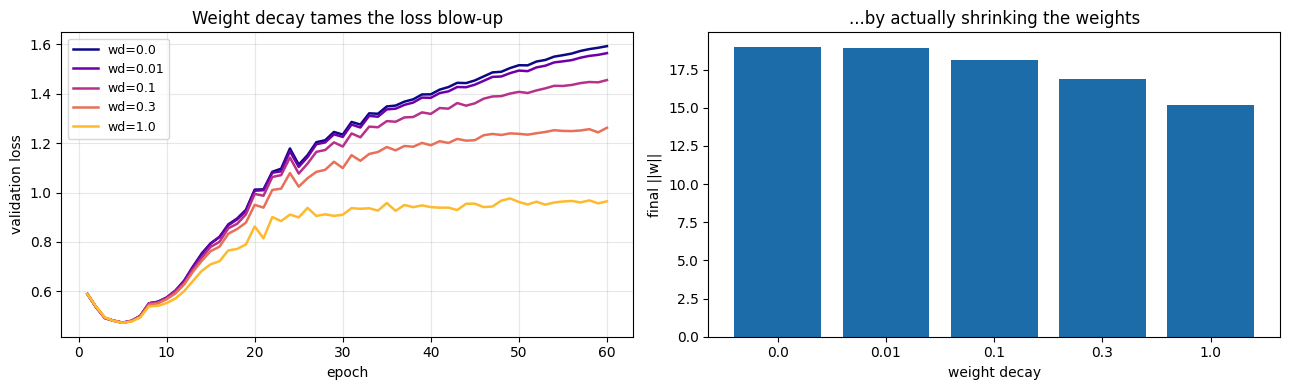

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
cols = plt.cm.plasma(np.linspace(0, 0.85, len(wd_runs)))
for c,(wd,r) in zip(cols, wd_runs.items()):
    hh=r["hist"]; e=[x["ep"] for x in hh]
    axes[0].plot(e, [x["vl"] for x in hh], color=c, lw=1.8, label=f"wd={wd}")
axes[0].set_ylabel("validation loss"); axes[0].set_title("Weight decay tames the loss blow-up")
ws = [torch.cat([p.detach().flatten() for p in r["model"].parameters()]).norm().item() for r in wd_runs.values()]
axes[1].bar([str(w) for w in wd_runs], ws, color="#1b6ca8")
axes[1].set_xlabel("weight decay"); axes[1].set_ylabel("final ||w||")
axes[1].set_title("...by actually shrinking the weights")
axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
plt.tight_layout(); plt.show()


Weight decay does what the mechanism predicts: as the coefficient increases, the final weight norm falls, and the validation-loss blow-up becomes less severe.

A **weight norm** is a single number summarising the overall magnitude of the model's parameters. A lower norm therefore confirms that the regulariser is actually changing the parameter values, not merely producing a coincidental change in the validation curve.

Be precise about the result. At the strongest setting, the validation-loss blow-up is reduced, not eliminated. At the smaller coefficients, the effect is barely visible in this experiment.

The validation AUC also changes much less than the validation loss. That is understandable from Section 4: weight decay is affecting the confidence and shape of the learned function, while AUC only cares about the ordering of predictions.

So the correct conclusion is not “weight decay improves AUC” or “weight decay does nothing.” The more precise conclusion is:

> **In this experiment, weight decay strongly changes parameter magnitude and reduces loss deterioration, while its effect on ranking quality is comparatively small.**

Notice another important difference from Section 5. The models can still reach training AUC of 1.0. Weight decay has not removed the model's capacity; it has changed which parameter configurations the optimiser prefers.

**Reduced capacity:** remove some of the model's ability to represent complicated functions.

**Weight decay:** keep the capacity, but discourage solutions that require large weights.

That distinction is worth remembering because the two methods can produce similar-looking improvements for different reasons.


<a id="s7"></a>
## 7. Dropout, and the bug everyone writes once

**Dropout** randomly sets some activations to zero during training.

An activation is the value produced by a neuron after its input has passed through the layer and activation function. With dropout, some of those values are temporarily removed on each training step.

This means the model cannot depend too heavily on any one unit being present. Across many updates it is encouraged to distribute useful information across multiple pathways instead of building a fragile solution that depends on a particular collection of units.

There is a crucial asymmetry:

- during **training**, dropout is active;
- during **evaluation**, dropout must be disabled.

PyTorch controls this behaviour through `model.train()` and `model.eval()`.

This is not just a cosmetic switch. It changes the behaviour of layers such as Dropout and BatchNorm. Forgetting to call `model.eval()` before validation or testing can therefore make your reported metric noisy or systematically wrong.

We will deliberately create that bug before fixing it.


In [14]:
drop_runs = {}
for p in [0.0, 0.2, 0.5, 0.8]:
    r = run(p_drop=p); drop_runs[p] = r
    hh=r["hist"]; vl_=[x["vl"] for x in hh]; va_=[x["va"] for x in hh]
    print(f"dropout={p:<4} best val loss {min(vl_):.4f}  final val loss {vl_[-1]:.4f}  "
          f"best val AUC {max(va_):.4f}  final train AUC {hh[-1]['tra']:.4f}")


dropout=0.0  best val loss 0.4733  final val loss 1.5929  best val AUC 0.8187  final train AUC 1.0000


dropout=0.2  best val loss 0.4652  final val loss 1.4917  best val AUC 0.8259  final train AUC 1.0000


dropout=0.5  best val loss 0.4553  final val loss 1.1959  best val AUC 0.8335  final train AUC 1.0000


dropout=0.8  best val loss 0.4548  final val loss 0.6066  best val AUC 0.8286  final train AUC 0.9794


In [15]:
# THE BUG: evaluating without model.eval()
m = drop_runs[0.5]["model"]

m.eval()                                   # correct
with torch.no_grad():
    p_correct = torch.sigmoid(m(Xv)).numpy().ravel()
auc_correct = roc_auc_score(y_va, p_correct)

m.train()                                  # WRONG: dropout still active at eval time
torch.manual_seed(0)
runs_buggy = []
for trial in range(5):
    with torch.no_grad():
        pb = torch.sigmoid(m(Xv)).numpy().ravel()
    runs_buggy.append(roc_auc_score(y_va, pb))
m.eval()

print(f"correct (model.eval()) : val AUC {auc_correct:.4f}   — identical every time")
print(f"buggy   (model.train()): val AUC {' '.join(f'{a:.4f}' for a in runs_buggy)}")
print(f"                         spread across 5 identical evaluations: "
      f"{max(runs_buggy)-min(runs_buggy):.4f} AUC")
print(f"                         mean penalty: {auc_correct-np.mean(runs_buggy):+.4f} AUC")


correct (model.eval()) : val AUC 0.7426   — identical every time
buggy   (model.train()): val AUC 0.7139 0.7505 0.6999 0.7520 0.7086
                         spread across 5 identical evaluations: 0.0521 AUC
                         mean penalty: +0.0176 AUC


Two symptoms identify this bug, and both are worth remembering.

### 1. The evaluation score can be worse than it should be

If dropout is still active, the model is being evaluated with randomly removed activations. You are therefore not evaluating the deterministic full network you intend to deploy.

### 2. Repeating the same evaluation gives different results

This is the giveaway.

If you evaluate the **same model on the same data** twice and the predictions or metrics change, some stochastic training behaviour is probably still active. In this experiment, leaving the model in training mode leaves dropout switched on.

A good development check is therefore simple: evaluate twice. If identical inputs and identical model parameters produce different predictions when you expect deterministic evaluation, investigate the model mode and other sources of randomness.

The same `train()`/`eval()` discipline matters for BatchNorm. In training mode, BatchNorm uses statistics computed from the current batch; in evaluation mode, it uses the running statistics collected during training. Note 3.3 covers BatchNorm in detail.

The dropout results themselves show a moderate reduction in the validation-loss blow-up, especially at stronger dropout rates. The effect on AUC is comparatively small in this experiment.

**Check your understanding.** A colleague reports 0.84 AUC during training but 0.81 after reloading the checkpoint in a separate evaluation script, and the model contains dropout. Give two possible explanations — one involving `model.eval()`, and one that does not — and describe the single check that would distinguish them.


<a id="s8"></a>
## 8. Early stopping

Section 3 showed validation loss reaching its minimum early and getting worse when training continued.

**Early stopping** turns that observation into a training rule:

1. monitor a validation metric;
2. remember the best value seen so far;
3. save the corresponding model parameters;
4. stop training when the metric has failed to improve for a chosen number of epochs.

That waiting period is called **patience**.

Early stopping is different from dropout and weight decay because it does not directly change the model architecture or add a penalty to the training objective. It changes **how long you train and which checkpoint you keep**.

In this experiment, that matters because the model is capable of continuing to reduce training loss after validation performance has already peaked.


In [16]:
def train_early_stopping(hidden=(256,128), p_drop=0.0, wd=0.0, lr=1e-3,
                         max_epochs=200, patience=10, bs=32, seed=SEED, verbose=True):
    model = make_mlp(hidden, p_drop, seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    g = torch.Generator().manual_seed(seed)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, Yt),
                                         batch_size=bs, shuffle=True, generator=g)
    best_vl, best_ep, best_state, since = float("inf"), 0, None, 0
    for ep in range(1, max_epochs+1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv), Yv).item()
        if vl < best_vl - 1e-5:
            best_vl, best_ep, since = vl, ep, 0
            best_state = copy.deepcopy(model.state_dict())      # RESTORE the best, don't just stop
        else:
            since += 1
            if since >= patience:
                if verbose: print(f"  stopped at epoch {ep}: no improvement for {patience} epochs")
                break
    model.load_state_dict(best_state)                           # <- the step people forget
    model.eval()
    with torch.no_grad():
        va = roc_auc_score(y_va, torch.sigmoid(model(Xv)).numpy().ravel())
        te = roc_auc_score(y_te, torch.sigmoid(model(Xs)).numpy().ravel())
    return dict(model=model, best_epoch=best_ep, best_vl=best_vl, val_auc=va, test_auc=te, ran=ep)

print("early stopping, big unregularised model:")
es_big = train_early_stopping()
print(f"  ran {es_big['ran']} epochs, restored epoch {es_big['best_epoch']}")
print(f"  val loss {es_big['best_vl']:.4f}  val AUC {es_big['val_auc']:.4f}  test AUC {es_big['test_auc']:.4f}")
print()
print("compare: same model trained a fixed 60 epochs with no early stopping")
final_model = base["model"]; final_model.eval()
with torch.no_grad():
    print(f"  val loss {base['hist'][-1]['vl']:.4f}  val AUC {base['hist'][-1]['va']:.4f}  "
          f"test AUC {roc_auc_score(y_te, torch.sigmoid(final_model(Xs)).numpy().ravel()):.4f}")


early stopping, big unregularised model:


  stopped at epoch 15: no improvement for 10 epochs
  ran 15 epochs, restored epoch 5
  val loss 0.4733  val AUC 0.8095  test AUC 0.7528

compare: same model trained a fixed 60 epochs with no early stopping
  val loss 1.5929  val AUC 0.7424  test AUC 0.7019


Three details in the implementation matter more than the basic concept.

### 1. Restore the best weights — do not merely stop

Suppose the best validation loss occurred at epoch 12 and your patience is 5. If you simply stop at epoch 17, you are holding the model from epoch 17, not the model that achieved the best validation result.

`load_state_dict(best_state)` restores the parameters from the best checkpoint.

So early stopping is really two operations:

> **choose when training should stop + keep the best model found before stopping.**

### 2. Patience must be large enough for normal validation noise

Validation loss does not necessarily improve smoothly every epoch. A small upward movement can happen even while the overall trend is improving.

A patience of 1 reacts to every small upward fluctuation. A patience of 10 requires the model to fail to improve for a much longer period before stopping.

The correct patience therefore depends partly on how noisy your validation measurement is.

### 3. Early stopping uses the validation set for model selection

The validation set is no longer a neutral measurement if you repeatedly use it to choose among checkpoints.

For example, if you inspect 200 checkpoints and keep the one with the best validation AUC, the final validation AUC is optimistic: you selected the checkpoint partly because that particular validation set liked it.

That is why this notebook keeps a separate **test set**. The test set is not used to choose the model or stopping point. It is held back for the final measurement.

This distinction becomes part of the experimental protocol in Day 4.

**Check your understanding.** Early stopping is sometimes described as “a regulariser that costs nothing.” Given the validation-set issue above, what does it actually cost? And if the validation set had only 30 rows, would you trust it to choose between 200 checkpoints? Explain why.


<a id="s9"></a>
## 9. Over-regularising, and how much noise your validation set has

Every regularisation method has a strength setting, and pushing that setting too far can create a different problem: **over-regularisation**.

Over-regularisation means the constraints have become strong enough that the model is no longer free to represent useful structure.

The visual pattern is often the opposite of ordinary overfitting:

- the model is constrained enough that it cannot fit the training data as closely;
- useful signal can be suppressed;
- both training and validation performance can suffer.

There is a second issue here that is easy to miss: **validation measurements are noisy**.

If two configurations differ by 0.005 AUC, that difference might be real — or it might simply be caused by which rows happened to be placed in the validation set.

This section therefore asks two questions:

1. What does over-regularisation look like?
2. How large does a validation difference need to be before we should take it seriously?


In [17]:
over = run(hidden=(16,8), p_drop=0.8, wd=1.0)
hh = over["hist"]
print("aggressively regularised: (16,8), dropout 0.8, weight decay 1.0")
print(f"  best val AUC      {max(x['va'] for x in hh):.4f}   <- looks GOOD")
print(f"  best val loss     {min(x['vl'] for x in hh):.4f}")
print(f"  final train AUC   {hh[-1]['tra']:.4f}   <- no memorisation at all")
print(f"  final val accuracy {hh[-1]['vacc']:.4f}")
print(f"  majority-class acc {max(y_va.mean(), 1-y_va.mean()):.4f}   <- compare the two lines above")
print()
m = over["model"]; m.eval()
with torch.no_grad():
    p = torch.sigmoid(m(Xv)).numpy().ravel()
print(f"  predicted P(bad): min {p.min():.3f}  max {p.max():.3f}  mean {p.mean():.3f}")
print(f"  predictions above 0.5: {(p>0.5).sum()} out of {len(p)}")
print()
print("  For comparison, the tiny-but-not-over-regularised (8,) model:")
t8 = cap_runs[(8,)]["hist"]
print(f"    best val AUC {max(x['va'] for x in t8):.4f}  best val loss {min(x['vl'] for x in t8):.4f}  "
      f"final val acc {t8[-1]['vacc']:.4f}")


aggressively regularised: (16,8), dropout 0.8, weight decay 1.0
  best val AUC      0.8424   <- looks GOOD
  best val loss     0.5514
  final train AUC   0.8408   <- no memorisation at all
  final val accuracy 0.7000
  majority-class acc 0.7000   <- compare the two lines above

  predicted P(bad): min 0.193  max 0.448  mean 0.331
  predictions above 0.5: 0 out of 250

  For comparison, the tiny-but-not-over-regularised (8,) model:
    best val AUC 0.8360  best val loss 0.4569  final val acc 0.7440


Here is the trap.

The over-regularised model has the highest **best validation AUC** in this notebook. If AUC were the only number you looked at, you might conclude that it is the best model.

But the rest of the evidence says something important. Its validation accuracy has collapsed to approximately the majority-class rate, and its predicted probabilities are compressed into a narrow range that rarely crosses the 0.5 decision threshold.

This exposes another limitation of AUC.

AUC is **threshold-free**: it evaluates how well the model orders examples across possible thresholds. It does not tell you whether a particular threshold, such as 0.5, will produce useful decisions.

So this model can still rank bad-credit cases above good-credit cases reasonably well while producing almost no positive classifications at the chosen threshold.

Compare this with Section 4:

- the overfitted model became **too confident** while retaining much of its ranking ability;
- the over-regularised model became **too cautious** while also retaining reasonable ranking ability.

AUC does not directly reveal either calibration problem.

The broader lesson is:

> **A metric can be excellent at measuring one property while being completely blind to another property you care about.**

Now we reach the question that should sit behind every comparison in this notebook:

**How large does a difference have to be before we can reasonably treat it as evidence of an improvement?**


In [18]:
# Measure the noise floor: same config, same seed, only the data split changes.
noise_aucs = []
for rs in range(10):
    Xa, Xb_, ya, yb_ = train_test_split(X_raw, y_raw, train_size=500, random_state=rs, stratify=y_raw)
    Xv2, _, yv2, _   = train_test_split(Xb_, yb_, test_size=0.5, random_state=rs, stratify=yb_)
    p2 = ColumnTransformer([("n", StandardScaler(), gnum),
                            ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gcat)])
    A1 = p2.fit_transform(Xa).astype(np.float32); A2 = p2.transform(Xv2).astype(np.float32)
    torch.manual_seed(SEED); g = torch.Generator().manual_seed(SEED)
    mm = nn.Sequential(nn.Linear(A1.shape[1],16), nn.ReLU(), nn.Linear(16,8), nn.ReLU(), nn.Linear(8,1))
    oo = torch.optim.AdamW(mm.parameters(), lr=1e-3)
    T1 = torch.tensor(A1); Y1 = torch.tensor(ya).unsqueeze(1)
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(T1,Y1), batch_size=32,
                                     shuffle=True, generator=g)
    for _ in range(20):
        mm.train()
        for xb,yb in dl: oo.zero_grad(); loss_fn(mm(xb),yb).backward(); oo.step()
    mm.eval()
    with torch.no_grad():
        noise_aucs.append(roc_auc_score(yv2, torch.sigmoid(mm(torch.tensor(A2))).numpy().ravel()))

noise_aucs = np.array(noise_aucs)
print("IDENTICAL configuration and seed, 10 different train/val splits:")
print("  " + "  ".join(f"{a:.4f}" for a in noise_aucs))
print()
print(f"  mean                {noise_aucs.mean():.4f}")
print(f"  standard deviation  {noise_aucs.std():.4f}")
print(f"  min to max spread   {noise_aucs.max()-noise_aucs.min():.4f}")
print()
print(f"  => a difference smaller than about {2*noise_aucs.std():.3f} AUC is not distinguishable")
print(f"     from noise with a validation set of this size.")


IDENTICAL configuration and seed, 10 different train/val splits:
  0.7777  0.7874  0.7714  0.7857  0.7928  0.7410  0.7789  0.7582  0.7899  0.7797

  mean                0.7763
  standard deviation  0.0151
  min to max spread   0.0517

  => a difference smaller than about 0.030 AUC is not distinguishable
     from noise with a validation set of this size.


That number should change how you read every table in this notebook.

The same model configuration and seed, evaluated on different validation splits, produces a noticeable spread in AUC. That spread is the **noise floor** of this measurement: the amount the reported score can move simply because the validation examples changed.

Two standard deviations are only a rough descriptive yardstick here, not a universal statistical significance test. But the practical message is clear: if the difference between two configurations is smaller than the normal variation of the measurement, the experiment has not established that one configuration is genuinely better.

This is why several close comparisons in Sections 6 and 7 should not be turned into confident rankings. The capacity effect in Section 5 is much larger and more consistent; many of the smaller dropout and weight-decay differences are within the range of ordinary validation variation.

Three habits follow:

- **Measure your noise floor before tuning.** Then you know what size of improvement your experiment can realistically resolve.
- **Report variability, not only a single point.** Repeat across splits or seeds when close comparisons matter.
- **Be suspicious of small gains after many trials.** If you try many configurations, one of them will often obtain an unusually good validation score by chance. Selecting that winner does not prove that the underlying configuration is better.

This is a central idea in empirical machine learning: **measurement noise and selection can create apparent improvements even when the underlying models are equally good.**

Day 4 turns these ideas into a more formal experimental protocol.

> **🖼 Image prompt** — A horizontal number line labelled "validation AUC", spanning roughly 0.74 to 0.84. Plot ten small dots scattered along it, all labelled collectively as "same config, same seed, 10 different splits" — showing them spread widely. Beneath, draw a shaded horizontal band spanning ±2 standard deviations, labelled "the noise floor". Above the line, place two clearly distinct markers labelled "config A" and "config B" positioned so they both fall *inside* the shaded band, with a caption: "A beat B. A did not beat B." The whole point is the visual collision between the apparent gap and the width of the band. Clean, minimal, one accent colour for the band.


<a id="s10"></a>
## 10. What to reach for first

The final table brings the interventions together.

The important question is not “Which technique has the highest number?” Instead, read the table alongside the mechanisms and the measurement noise from Section 9.

The test set is included here because it has been kept separate from model selection. A test score is meaningful only to the extent that we have not repeatedly used the test set to choose the model.


In [19]:
configs = [
    ("no regularisation, (256,128)", dict(hidden=(256,128))),
    ("weight decay 1.0",             dict(hidden=(256,128), wd=1.0)),
    ("dropout 0.5",                  dict(hidden=(256,128), p_drop=0.5)),
    ("dropout 0.5 + wd 0.1",         dict(hidden=(256,128), p_drop=0.5, wd=0.1)),
    ("smaller model (16,8)",         dict(hidden=(16,8))),
    ("tiny model (8,)",              dict(hidden=(8,))),
    ("(16,8) + dropout 0.3 + wd 0.1",dict(hidden=(16,8), p_drop=0.3, wd=0.1)),
    ("OVER-regularised (16,8) p.8 wd1", dict(hidden=(16,8), p_drop=0.8, wd=1.0)),
]
print(f"{'configuration':<34}{'val AUC':>9}{'test AUC':>10}{'val loss':>10}{'stop ep':>9}")
print("=" * 72)
table = []
for name, kw in configs:
    r = train_early_stopping(verbose=False, **kw)
    table.append((name, r))
    print(f"{name:<34}{r['val_auc']:>9.4f}{r['test_auc']:>10.4f}{r['best_vl']:>10.4f}{r['best_epoch']:>9}")

print("-" * 72)
print(f"{'majority-class baseline (AUC)':<34}{0.5:>9.4f}{0.5:>10.4f}")
print()
print(f"noise floor (2 sd, measured in section 9): {2*noise_aucs.std():.4f} AUC")
best_test = max(table, key=lambda t: t[1]["test_auc"])
within = [n for n, r in table if best_test[1]["test_auc"] - r["test_auc"] < 2*noise_aucs.std()]
print(f"configurations statistically indistinguishable from the best on TEST: {len(within)} of {len(table)}")
for n in within: print(f"   - {n}")


configuration                       val AUC  test AUC  val loss  stop ep


no regularisation, (256,128)         0.8095    0.7528    0.4733        5


weight decay 1.0                     0.8112    0.7544    0.4723        5


dropout 0.5                          0.8288    0.7656    0.4553        7


dropout 0.5 + wd 0.1                 0.8293    0.7659    0.4552        7


smaller model (16,8)                 0.8192    0.7619    0.4644       20


tiny model (8,)                      0.8278    0.7637    0.4569       37


(16,8) + dropout 0.3 + wd 0.1        0.8201    0.7685    0.4611       37


OVER-regularised (16,8) p.8 wd1      0.8288    0.7622    0.5338       88
------------------------------------------------------------------------
majority-class baseline (AUC)        0.5000    0.5000

noise floor (2 sd, measured in section 9): 0.0302 AUC
configurations statistically indistinguishable from the best on TEST: 8 of 8
   - no regularisation, (256,128)
   - weight decay 1.0
   - dropout 0.5
   - dropout 0.5 + wd 0.1
   - smaller model (16,8)
   - tiny model (8,)
   - (16,8) + dropout 0.3 + wd 0.1
   - OVER-regularised (16,8) p.8 wd1


Read that last block of output carefully. The most important result is not a tidy ranking of regularisers.

Once early stopping is applied, the configurations in the final table are statistically indistinguishable **within the resolution of this experiment** on the untouched test set. The spread is smaller than the noise floor measured in Section 9.

That does not prove that the methods are universally equivalent. It means that **this experiment, with this dataset, split, model family, seeds, and sample size, does not provide enough evidence to separate them reliably on the test measurement**.

That distinction matters. “We cannot distinguish them here” is different from “they are mathematically identical.”

### What to take away

**1. Overfitting requires enough freedom relative to the available data.**

The Bank Marketing setup showed only mild overfitting in this experiment. German Credit, with only 500 training rows and a much larger model relative to the dataset, made the failure obvious.

Before choosing a fix, first establish that the failure mode exists.

**2. Validation loss and validation AUC answer different questions.**

Loss is sensitive to confidence as well as correctness. AUC focuses on ranking. The overfitted model stayed a useful ranker for longer than it remained a well-behaved probability estimator, while the over-regularised model could retain ranking ability while producing predictions that were too compressed for a 0.5 decision threshold.

**3. Early stopping mattered strongly in this experiment.**

With a fixed 60-epoch budget, capacity appeared to produce large differences because the larger models were allowed to continue past their useful checkpoints. When early stopping is applied, those differences largely disappear on the final test measurement.

So part of what the other regularisation methods appeared to accomplish was simply preventing the model from being trained beyond the point where validation performance was best.

That is a conclusion about **this experiment**, not a universal claim that early stopping makes every other regulariser unnecessary.

**4. Restore the best weights.**

Stopping at the end of the patience window is not enough. You must keep the parameters from the best validation checkpoint; otherwise you deliberately return to a later, worse model.

**5. Measure the noise floor before trusting a ranking.**

This is the habit that turns the notebook from a list of techniques into an experimental method.

If two configurations differ by less than the normal variability of your validation/test measurement, the honest conclusion may be that your experiment cannot yet tell them apart.

That is not a disappointing result. It is useful information about the resolution of your experiment.

The next step is to formalise that discipline: control the split, seeds, model-selection procedure, and final evaluation so that improvements are separated from noise.
